# Stage 8 – Monotonic constraints

Banks need a credit model whose behaviour a credit officer can defend: a higher interest rate or debt-to-income should never *lower* someone's predicted risk, and a higher income or FICO score should never *raise* it. Unconstrained gradient boosting can learn such wiggles from noise.

This notebook reuses the leak-free preprocessing from notebook 03 (same sample and split), then trains XGBoost twice, with and without `monotone_constraints`, and compares:

1. accuracy (ROC AUC, PR AUC),
2. how often each model moves risk the wrong way when a feature gets worse,
3. partial dependence curves for key features.


## 1. Load and prepare data (same as notebook 03)

In [1]:
# 08_monotonic_constraints.ipynb
# ===========================================================
# Stage 8: Monotonic constraints
# Same leak-free preprocessing as notebook 03 (same sample, same split),
# then XGBoost trained with and without monotonic constraints.
# ===========================================================

import os
import gc
import random
import warnings

from typing import List

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# Modeling / preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    auc,
)

import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
import shap

warnings.filterwarnings("ignore")
tqdm.pandas()

# -----------------------------------------------------------
# CONFIG
# -----------------------------------------------------------
# Cleaned dataset from Notebook 1. The first path that exists is used.
DATA_CANDIDATES = [
    "../data/accepted_cleaned.csv",                                   # repo layout
    r"D:\credit-risk-xai\credit-risk-xai\data\accepted_cleaned.csv",  # my local copy
]
INPUT_FILE = next((p for p in DATA_CANDIDATES if os.path.exists(p)), DATA_CANDIDATES[0])
print("Using data file:", INPUT_FILE)
SAMPLE_TARGET = 200_000                      # rows to sample (None => full file, but heavy)
RANDOM_STATE = 42
TEST_SIZE = 0.20
N_FOLDS_FOR_TE = 5                           # for target-mean encoding
SAVE_DIR = "../outputs/notebook8_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

TARGET_COL = "default"   # created in Notebook 1: 1 = default, 0 = fully paid

# -----------------------------------------------------------
# Utility: memory-safe reservoir sampling from CSV
# -----------------------------------------------------------
def reservoir_sample_csv(
    path: str,
    sample_size: int,
    random_state: int = 42,
    chunksize: int = 100_000,
):
    """
    Reservoir sampling for large CSV.
    Returns: sampled_df (pandas), total_rows_read (int)
    """
    rng = random.Random(random_state)
    reservoir = []
    total = 0

    reader = pd.read_csv(
        path,
        compression="infer",
        chunksize=chunksize,
        low_memory=True
    )

    for chunk in tqdm(reader, desc="Streaming CSV for sampling"):
        for _, row in chunk.iterrows():
            if total < sample_size:
                reservoir.append(row)
            else:
                j = rng.randrange(total + 1)
                if j < sample_size:
                    reservoir[j] = row
            total += 1
        del chunk
        gc.collect()

    if total == 0:
        raise FileNotFoundError(f"No rows read from {path}")

    sampled_df = pd.DataFrame(reservoir).reset_index(drop=True)
    return sampled_df, total

# -----------------------------------------------------------
# 1) Sampling / loading dataset
# -----------------------------------------------------------
print("1) Sampling/loading dataset...")

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(f"Input file not found: {INPUT_FILE}")

if SAMPLE_TARGET is not None:
    df, total_rows = reservoir_sample_csv(
        INPUT_FILE,
        sample_size=SAMPLE_TARGET,
        random_state=RANDOM_STATE,
    )
    print(f"Sampled {len(df)} rows from {total_rows} total rows.")
else:
    df = pd.read_csv(INPUT_FILE, low_memory=True)
    total_rows = len(df)
    print(f"Loaded full cleaned dataset: {df.shape}")

# -----------------------------------------------------------
# 2) Create binary target & drop leakage columns
# -----------------------------------------------------------
print("2) Create binary target and drop leakage cols if present...")

# Ensure target exists
if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in cleaned dataset.")

# Coerce target to int (0/1)
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce").fillna(0).astype(int)

# Explicit leakage columns: payment/outcome info etc.
leak_cols_explicit = [
    "loan_status",              # original text outcome (categorical)
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "last_pymnt_amnt",
    "recoveries",
    "collection_recovery_fee",
    "last_pymnt_d",
    "next_pymnt_d",
    "last_credit_pull_d",
    "out_prncp",
    "out_prncp_inv",
    "settlement_status",
    "settlement_date",
    "settlement_amount",
    "settlement_percentage",
    # ❗ Not available at application time / outcome-related
    "debt_settlement_flag",
]

# FICO at end of loan – future info
leak_cols_explicit += [
    "last_fico_range_low",
    "last_fico_range_high",
]

# Pure identifiers / text / region that we don't want as features
leak_cols_explicit += [
    "id",          # ❗ drop ID as feature
    "desc",
    "url",
    "title",
    "zip_code",
    "addr_state",
    "policy_code",
]


drop_now = [c for c in leak_cols_explicit if c in df.columns]
if drop_now:
    df.drop(columns=drop_now, inplace=True)
    print(f"--> Dropped explicit leakage columns: {drop_now}")

# Drop constant/all-null columns
nunique = df.nunique(dropna=True)
const_cols = [c for c in df.columns if nunique.get(c, 0) <= 1 and c != TARGET_COL]
if const_cols:
    df.drop(columns=const_cols, inplace=True)
    print(f"--> Dropped constant/all-null columns: {const_cols}")

print("Remaining columns:", len(df.columns))

# -----------------------------------------------------------
# 3) Detect numeric vs categorical features (robust)
# -----------------------------------------------------------
print("3) Detect numeric vs categorical features (robust detection)...")

# List candidate feature columns (exclude target)
feature_cols = [c for c in df.columns if c != TARGET_COL]

numeric_cols: List[str] = []
categorical_cols: List[str] = []

for c in feature_cols:
    # Take a sample to inspect type
    sample = df[c].dropna().head(500)
    # Try numeric conversion
    sample_num = pd.to_numeric(sample, errors="coerce")
    non_na = len(sample_num.dropna())
    frac_numeric = non_na / max(len(sample), 1)

    # Heuristic:
    # - mostly numeric values => numeric
    # - or high cardinality numeric-like strings
    if frac_numeric > 0.8:
        numeric_cols.append(c)
    else:
        categorical_cols.append(c)

print(f"Detected numeric columns: {len(numeric_cols)}, categorical columns: {len(categorical_cols)}")
print("Numeric examples:", numeric_cols[:10])
print("Categorical examples:", categorical_cols[:10])

# -----------------------------------------------------------
# 4) Coerce numeric columns & clean categorical
# -----------------------------------------------------------
print("4) Coercing numeric columns & cleaning categoricals...")

for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# For categorical: fill NaN with token and cast to string
if categorical_cols:
    df[categorical_cols] = df[categorical_cols].astype(str).fillna("__MISSING__")

# -----------------------------------------------------------
# 5) Split categorical by cardinality
# -----------------------------------------------------------
print("5) Splitting categorical columns by cardinality...")

small_cat = []
large_cat = []
for c in categorical_cols:
    nun = df[c].nunique()
    if nun < 20:
        small_cat.append(c)
    else:
        large_cat.append(c)

print(f"Small-cardinality: {len(small_cat)}  Large-cardinality: {len(large_cat)}")

# If too many large-cat, restrict to top-freq columns
MAX_LARGE_USE = 8
if len(large_cat) > MAX_LARGE_USE:
    # keep those with highest frequency mass in top-100 categories
    freq_sorted = sorted(
        large_cat,
        key=lambda col: df[col].value_counts().iloc[:100].sum(),
        reverse=True
    )
    keep_large = freq_sorted[:MAX_LARGE_USE]
    drop_large_from_te = [c for c in large_cat if c not in keep_large]
    print(f"Reducing large-cardinality columns for TE to top {MAX_LARGE_USE}. Ignoring TE on: {drop_large_from_te}")
    large_cat = keep_large
    # The dropped large-card cols remain in 'small_cat' with truncated labels
    for c in drop_large_from_te:
        df[c] = df[c].apply(lambda s: s if len(s) <= 30 else s[:30])
        small_cat.append(c)

###############################################################################
# 6. Train/test split FIRST (before any target-based encoding)
#    Fix: previously the split happened after target encoding, so category
#    means were computed using test rows too (target leakage).
###############################################################################
print("6) Train/test split (stratified) BEFORE encoding...")

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df[TARGET_COL],
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
y_train = train_df[TARGET_COL].astype(int)
y_test = test_df[TARGET_COL].astype(int)
print(f"Train rows: {len(train_df)}  Test rows: {len(test_df)}")

###############################################################################
# 7. Target-mean encoding, fitted on TRAIN only
#    - train rows: out-of-fold means (a row never sees its own label)
#    - test rows: means learned from the full training set
#    - smoothing pulls rare categories towards the global mean
###############################################################################
print("7) Leak-free target encoding (out-of-fold on train, train means on test)...")

TE_SMOOTHING = 20
global_mean = y_train.mean()

def smoothed_means(frame, col):
    stats = frame.groupby(col)[TARGET_COL].agg(["mean", "count"])
    return (stats["mean"] * stats["count"] + global_mean * TE_SMOOTHING) / (stats["count"] + TE_SMOOTHING)

X_te_train = pd.DataFrame(index=train_df.index)
X_te_test = pd.DataFrame(index=test_df.index)
te_encoders = {}

skf = StratifiedKFold(n_splits=N_FOLDS_FOR_TE, shuffle=True, random_state=RANDOM_STATE)
for col in large_cat:
    print(f"  TE -> {col}")
    oof = pd.Series(global_mean, index=train_df.index, dtype=float)
    for fit_idx, enc_idx in skf.split(train_df, y_train):
        means = smoothed_means(train_df.iloc[fit_idx], col)
        oof.iloc[enc_idx] = train_df[col].iloc[enc_idx].map(means).fillna(global_mean).values
    X_te_train[col + "_te"] = oof.values

    full_means = smoothed_means(train_df, col)
    te_encoders[col] = full_means.to_dict()
    X_te_test[col + "_te"] = test_df[col].map(full_means).fillna(global_mean).values

###############################################################################
# 8. Ordinal-encode small-cardinality categoricals (fit on TRAIN only)
###############################################################################
print("8) Ordinal-encoding small-cardinality categorical features (fit on train)...")

if small_cat:
    ordinal_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    ord_names = [c + "_ord" for c in small_cat]
    X_ord_train = pd.DataFrame(ordinal_encoder.fit_transform(train_df[small_cat].astype(str)),
                               columns=ord_names, index=train_df.index)
    X_ord_test = pd.DataFrame(ordinal_encoder.transform(test_df[small_cat].astype(str)),
                              columns=ord_names, index=test_df.index)
else:
    ordinal_encoder = None
    X_ord_train = pd.DataFrame(index=train_df.index)
    X_ord_test = pd.DataFrame(index=test_df.index)

###############################################################################
# 9. Assemble train / test feature matrices
###############################################################################
print("9) Assembling feature matrices...")

numeric_cols_final = [c for c in numeric_cols if c in df.columns and c != TARGET_COL]

X_train = pd.concat([train_df[numeric_cols_final], X_ord_train, X_te_train], axis=1)
X_test = pd.concat([test_df[numeric_cols_final], X_ord_test, X_te_test], axis=1)
X_all = X_train  # kept so later cleanup code still works
feature_names = X_train.columns.tolist()
small_cat_used = list(small_cat)
large_cat_used = list(large_cat)

print(f"Train: {X_train.shape} Test: {X_test.shape}")

# -----------------------------------------------------------
# 10) Impute numeric features and scale
# -----------------------------------------------------------
print("10) Impute numeric features and scale (fit on train only)...")

preprocessor_num = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

if len(numeric_cols_final) > 0:
    X_train_num = preprocessor_num.fit_transform(X_train[numeric_cols_final])
    X_test_num = preprocessor_num.transform(X_test[numeric_cols_final])
else:
    # no numeric features
    X_train_num = np.empty((X_train.shape[0], 0))
    X_test_num = np.empty((X_test.shape[0], 0))

# The remaining columns (ordinal + TE) are already numeric, with no NaN
other_cols = [c for c in X_all.columns if c not in numeric_cols_final]
X_train_other = X_train[other_cols].to_numpy(dtype=float)
X_test_other = X_test[other_cols].to_numpy(dtype=float)

# Final matrices
X_train_final = np.hstack([X_train_num, X_train_other])
X_test_final = np.hstack([X_test_num, X_test_other])
final_feature_names = list(numeric_cols_final) + other_cols

print("Final matrices shapes:", X_train_final.shape, X_test_final.shape)

# Cleanup big objects
del X_train_num, X_test_num, X_train_other, X_test_other
gc.collect()



d:\anaconda\envs\credit-risk-xai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using data file: D:\credit-risk-xai\credit-risk-xai\data\accepted_cleaned.csv
1) Sampling/loading dataset...


Streaming CSV for sampling: 14it [01:54,  8.15s/it]


Sampled 200000 rows from 1345310 total rows.
2) Create binary target and drop leakage cols if present...
--> Dropped explicit leakage columns: ['out_prncp', 'out_prncp_inv', 'debt_settlement_flag', 'last_fico_range_low', 'last_fico_range_high', 'id']
--> Dropped constant/all-null columns: ['hardship_flag']
Remaining columns: 86
3) Detect numeric vs categorical features (robust detection)...
Detected numeric columns: 74, categorical columns: 11
Numeric examples: ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high']
Categorical examples: ['term', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'earliest_cr_line', 'initial_list_status']
4) Coercing numeric columns & cleaning categoricals...
5) Splitting categorical columns by cardinality...
Small-cardinality: 8  Large-cardinality: 3
6) Train/test split (stratified) BEFORE encoding...
Train rows

9

## 2. Direction rules

In [2]:
# -----------------------------------------------------------
# 11) Define the direction each feature is allowed to push risk
#     +1 = higher value -> higher default risk
#     -1 = higher value -> lower default risk
#      0 = no constraint (the model is free to learn any shape)
# -----------------------------------------------------------
DIRECTION_RULES = {
    # cost and burden of the loan
    "int_rate": +1,
    "dti": +1,
    "revol_util": +1,
    "bc_util": +1,
    "all_util": +1,
    "percent_bc_gt_75": +1,
    # past credit problems
    "delinq_2yrs": +1,
    "pub_rec": +1,
    "pub_rec_bankruptcies": +1,
    "num_accts_ever_120_pd": +1,
    "num_tl_90g_dpd_24m": +1,
    "inq_last_6mths": +1,
    "inq_last_12m": +1,
    # target-encoded columns are "default rate of this category", so higher = riskier
    "sub_grade_te": +1,
    "emp_title_te": +1,
    "earliest_cr_line_te": +1,
    # LendingClub grade A..G and 36 vs 60 months, ordinal-encoded in that order
    "grade_ord": +1,
    "term_ord": +1,
    # capacity and credit quality
    "annual_inc": -1,
    "fico_range_low": -1,
    "fico_range_high": -1,
    "pct_tl_nvr_dlq": -1,
}

constraints = [DIRECTION_RULES.get(f, 0) for f in final_feature_names]
constrained_feats = {f: DIRECTION_RULES[f] for f in final_feature_names if f in DIRECTION_RULES}
constraint_str = "(" + ",".join(str(c) for c in constraints) + ")"

print(f"Constrained {len(constrained_feats)} of {len(final_feature_names)} features:")
for f, d in constrained_feats.items():
    print(f"  {f:28s} {'higher = riskier' if d > 0 else 'higher = safer'}")
missing = [f for f in DIRECTION_RULES if f not in final_feature_names]
if missing:
    print("\nRules skipped (feature not in this dataset):", missing)


Constrained 22 of 85 features:
  int_rate                     higher = riskier
  annual_inc                   higher = safer
  dti                          higher = riskier
  delinq_2yrs                  higher = riskier
  fico_range_low               higher = safer
  fico_range_high              higher = safer
  inq_last_6mths               higher = riskier
  pub_rec                      higher = riskier
  revol_util                   higher = riskier
  all_util                     higher = riskier
  inq_last_12m                 higher = riskier
  bc_util                      higher = riskier
  num_accts_ever_120_pd        higher = riskier
  num_tl_90g_dpd_24m           higher = riskier
  pct_tl_nvr_dlq               higher = safer
  percent_bc_gt_75             higher = riskier
  pub_rec_bankruptcies         higher = riskier
  term_ord                     higher = riskier
  grade_ord                    higher = riskier
  sub_grade_te                 higher = riskier
  emp_title_te   

## 3. Train both models

In [3]:
# -----------------------------------------------------------
# 12) Train both models with identical settings
#     (validation set carved from train for early stopping; test untouched)
# -----------------------------------------------------------
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_final, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)

BASE_PARAMS = dict(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    n_estimators=600,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

def fit_xgb(extra):
    model = xgb.XGBClassifier(**BASE_PARAMS, **extra)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    return model

print("Training unconstrained XGBoost...")
xgb_free = fit_xgb({})
print("Training constrained XGBoost...")
xgb_mono = fit_xgb({"monotone_constraints": constraint_str})

def scores(model):
    p = model.predict_proba(X_test_final)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, p)
    return roc_auc_score(y_test, p), auc(rec, prec), p

roc_free, pr_free, p_free = scores(xgb_free)
roc_mono, pr_mono, p_mono = scores(xgb_mono)

comparison = pd.DataFrame(
    [["XGBoost (unconstrained)", roc_free, pr_free],
     ["XGBoost (monotonic)", roc_mono, pr_mono]],
    columns=["Model", "ROC_AUC", "PR_AUC"],
)
print(comparison.round(4).to_string(index=False))
print(f"\nROC AUC cost of constraints: {roc_free - roc_mono:+.4f}")
comparison.to_csv(os.path.join(SAVE_DIR, "monotonic_comparison.csv"), index=False)


Training unconstrained XGBoost...
Training constrained XGBoost...
                  Model  ROC_AUC  PR_AUC
XGBoost (unconstrained)   0.7273  0.4014
    XGBoost (monotonic)   0.7257  0.3952

ROC AUC cost of constraints: +0.0016


## 4. Wrong-direction check

In [4]:
# -----------------------------------------------------------
# 13) Does each model behave sensibly?
#     For 2,000 test applicants, nudge one feature in the "riskier" direction
#     by 0.5 standard deviations and check whether predicted risk went DOWN.
#     A sensible model should never do that.
# -----------------------------------------------------------
rng = np.random.RandomState(RANDOM_STATE)
check_idx = rng.choice(X_test_final.shape[0], size=min(2000, X_test_final.shape[0]), replace=False)
X_check = X_test_final[check_idx]
STEP = 0.5  # features are standardised, so 0.5 = half a standard deviation (TE/ordinal cols use their own std)

rows = []
for f, d in constrained_feats.items():
    j = final_feature_names.index(f)
    step = STEP * (np.nanstd(X_test_final[:, j]) or 1.0)
    X_up = X_check.copy()
    X_up[:, j] = X_up[:, j] + d * step          # move towards "riskier"
    for name, model in [("unconstrained", xgb_free), ("monotonic", xgb_mono)]:
        before = model.predict_proba(X_check)[:, 1]
        after = model.predict_proba(X_up)[:, 1]
        wrong = np.mean(after < before - 1e-6)  # risk fell when it should not
        rows.append({"feature": f, "model": name, "pct_wrong_direction": 100 * wrong})

violations = (pd.DataFrame(rows)
              .pivot(index="feature", columns="model", values="pct_wrong_direction")
              .sort_values("unconstrained", ascending=False))
print("% of applicants whose predicted risk moved the WRONG way:")
print(violations.round(1).to_string())
print(f"\nAverage across features -> unconstrained: {violations['unconstrained'].mean():.1f}%, "
      f"monotonic: {violations['monotonic'].mean():.1f}%")
violations.to_csv(os.path.join(SAVE_DIR, "monotonic_violations.csv"))


% of applicants whose predicted risk moved the WRONG way:
model                  monotonic  unconstrained
feature                                        
int_rate                     0.0           64.8
earliest_cr_line_te          0.0           46.7
pct_tl_nvr_dlq               0.0           34.8
bc_util                      0.0           30.6
annual_inc                   0.0           14.7
emp_title_te                 0.0           14.7
revol_util                   0.0           11.8
all_util                     0.0            9.0
percent_bc_gt_75             0.0            8.5
fico_range_low               0.0            7.4
sub_grade_te                 0.0            7.2
dti                          0.0            5.4
fico_range_high              0.0            4.1
delinq_2yrs                  0.0            0.0
num_accts_ever_120_pd        0.0            0.0
inq_last_6mths               0.0            0.0
inq_last_12m                 0.0            0.0
grade_ord                    0

## 5. Partial dependence

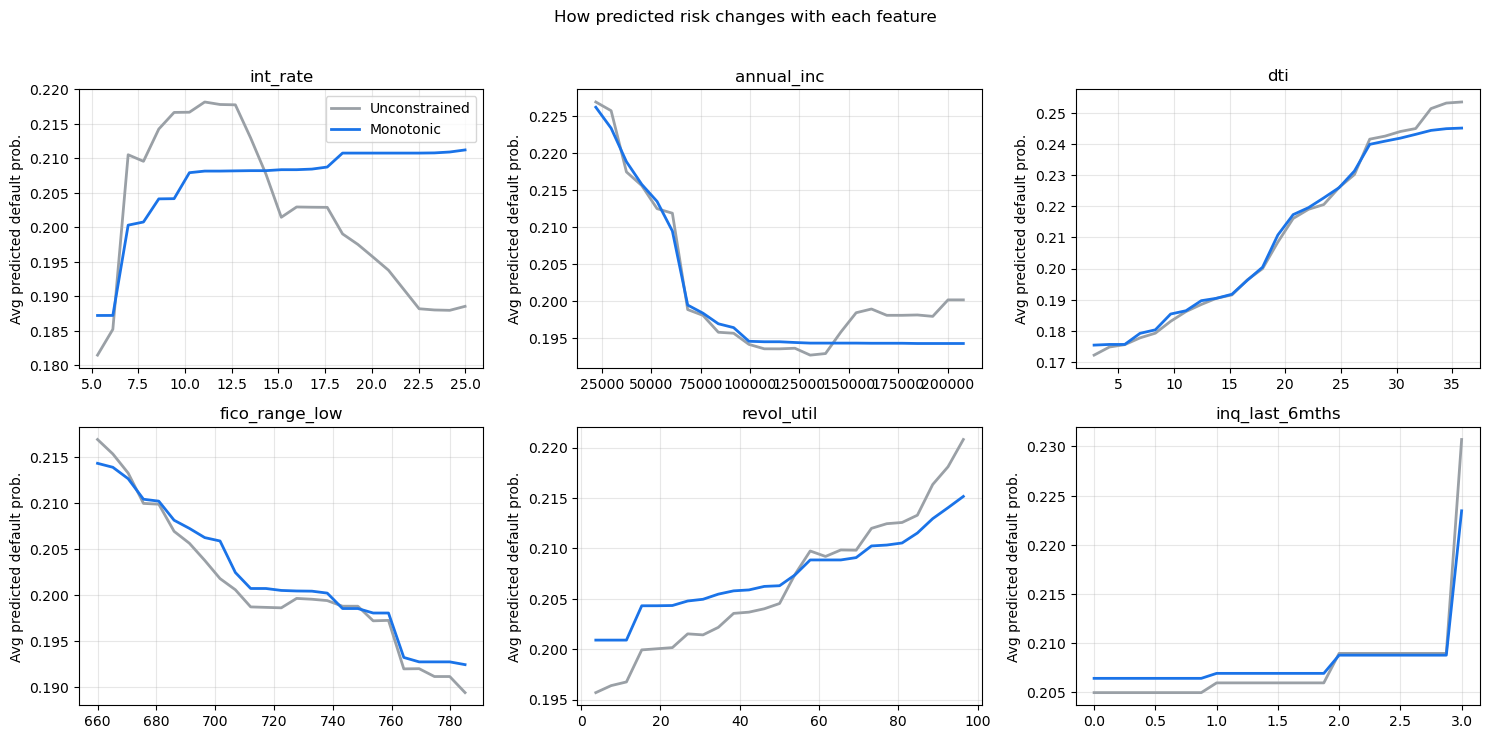

Saved: ../outputs/notebook8_outputs\monotonic_partial_dependence.png


In [5]:
# -----------------------------------------------------------
# 14) Plot: average predicted risk as one feature changes (partial dependence)
# -----------------------------------------------------------
def pd_curve(model, j, grid, X_base):
    out = []
    for v in grid:
        Xg = X_base.copy()
        Xg[:, j] = v
        out.append(model.predict_proba(Xg)[:, 1].mean())
    return np.array(out)

plot_feats = [f for f in ["int_rate", "annual_inc", "dti", "fico_range_low", "revol_util", "inq_last_6mths"]
              if f in final_feature_names][:6]
X_base = X_check[:500]
ncols = 3
nrows = int(np.ceil(len(plot_feats) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.6 * nrows), squeeze=False)

num_idx = {c: i for i, c in enumerate(numeric_cols_final)}
for ax, f in zip(axes.ravel(), plot_feats):
    j = final_feature_names.index(f)
    col = X_test_final[:, j]
    grid = np.linspace(np.nanpercentile(col, 2), np.nanpercentile(col, 98), 25)
    # show the x-axis in original units when the feature was standardised
    if f in num_idx:
        k = num_idx[f]
        scaler = preprocessor_num.named_steps["scaler"]
        x_axis = grid * scaler.scale_[k] + scaler.mean_[k]
    else:
        x_axis = grid
    ax.plot(x_axis, pd_curve(xgb_free, j, grid, X_base), label="Unconstrained", color="#9aa0a6", linewidth=2)
    ax.plot(x_axis, pd_curve(xgb_mono, j, grid, X_base), label="Monotonic", color="#1a73e8", linewidth=2)
    ax.set_title(f)
    ax.set_ylabel("Avg predicted default prob.")
    ax.grid(alpha=0.3)
for ax in axes.ravel()[len(plot_feats):]:
    ax.axis("off")
axes.ravel()[0].legend()
plt.suptitle("How predicted risk changes with each feature", y=1.02)
plt.tight_layout()
plot_path = os.path.join(SAVE_DIR, "monotonic_partial_dependence.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", plot_path)


## 6. SHAP and save

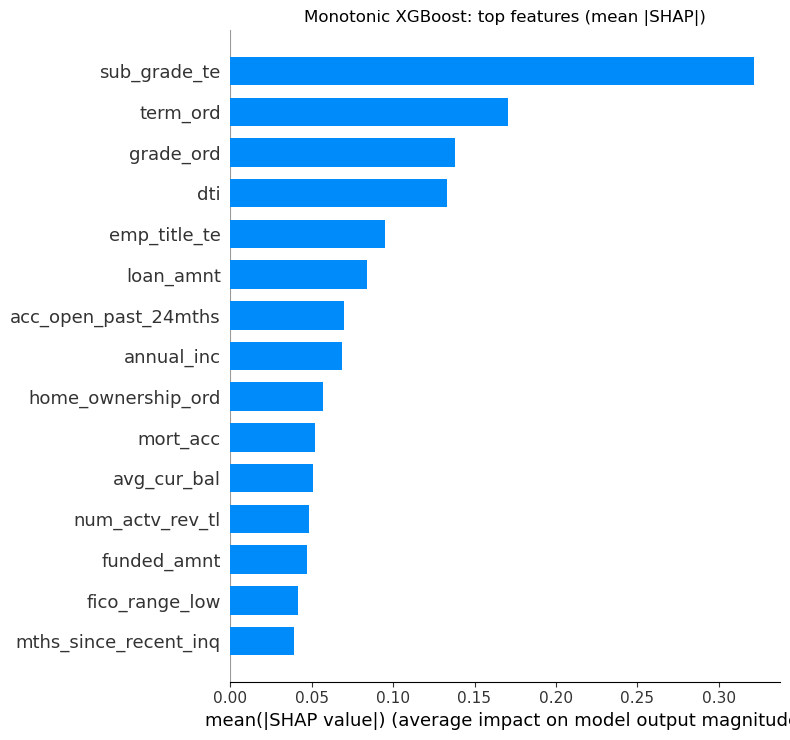


=== Summary ===
Unconstrained ROC AUC: 0.7273 | Monotonic ROC AUC: 0.7257 | cost: +0.0016
Wrong-direction predictions: 11.8% -> 0.0%
All outputs saved in: ../outputs/notebook8_outputs


In [6]:
# -----------------------------------------------------------
# 15) SHAP summary for the constrained model + save
# -----------------------------------------------------------
try:
    import shap
    shap_idx = check_idx[:1000]
    explainer = shap.TreeExplainer(xgb_mono)
    sv = explainer.shap_values(X_test_final[shap_idx])
    shap.summary_plot(sv, X_test_final[shap_idx], feature_names=final_feature_names,
                      plot_type="bar", max_display=15, show=False)
    plt.title("Monotonic XGBoost: top features (mean |SHAP|)")
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "monotonic_shap_bar.png"), dpi=200, bbox_inches="tight")
    plt.show()
except Exception as e:
    print("SHAP step skipped:", e)

joblib.dump({"model": xgb_mono, "constraints": constrained_feats, "feature_names": final_feature_names},
            os.path.join(SAVE_DIR, "xgb_monotonic.joblib"))

print("\n=== Summary ===")
print(f"Unconstrained ROC AUC: {roc_free:.4f} | Monotonic ROC AUC: {roc_mono:.4f} | cost: {roc_free - roc_mono:+.4f}")
print(f"Wrong-direction predictions: {violations['unconstrained'].mean():.1f}% -> {violations['monotonic'].mean():.1f}%")
print("All outputs saved in:", SAVE_DIR)
